✅ Libraries imported successfully!
⚠️  URL unavailable — generating representative dataset...
✅ Synthetic dataset created with 750 rows.
Shape after cleaning: (750, 10)

Missing values:
Unemployment_Rate       0
Employed                0
Labour_Participation    0
dtype: int64

Date range: 2019-01-01 to 2021-06-01


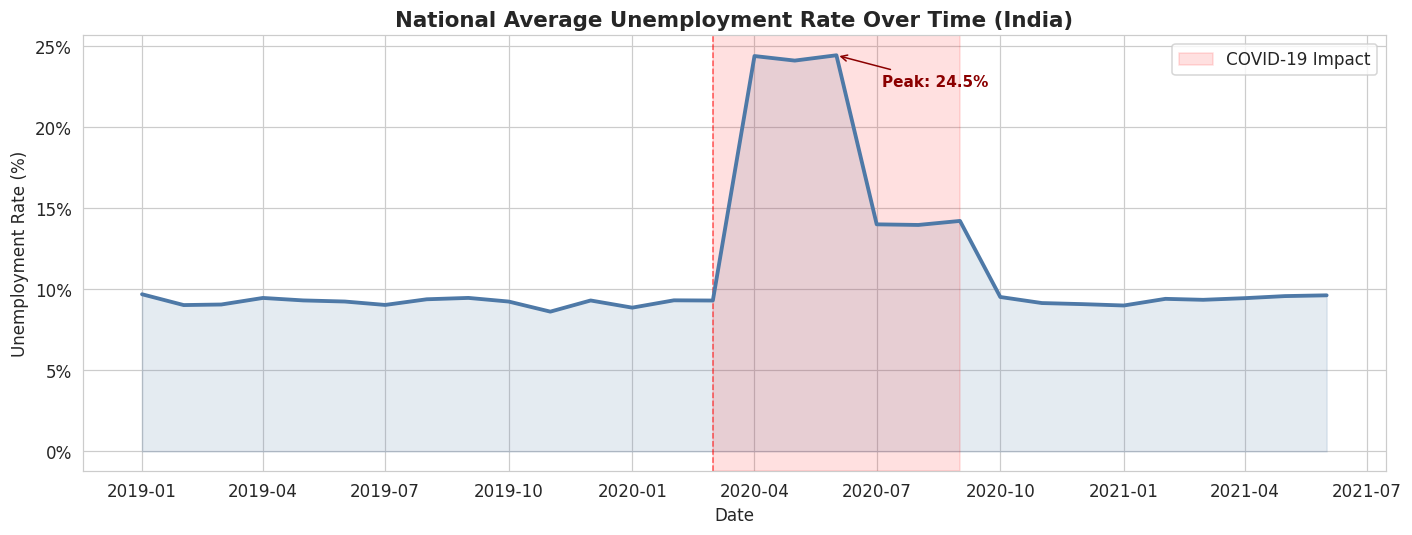

📌 A sharp spike in unemployment is clearly visible during the COVID-19 lockdown (Apr–Jun 2020).


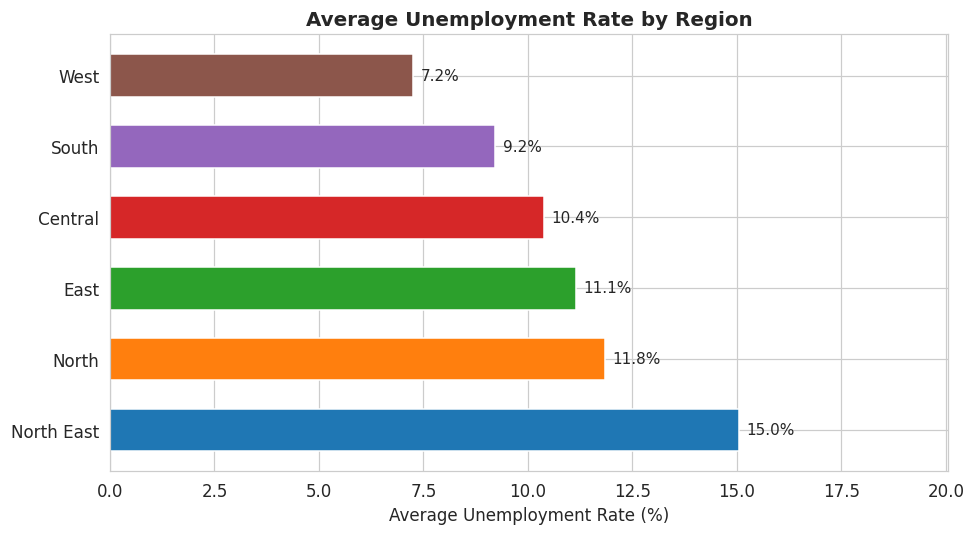

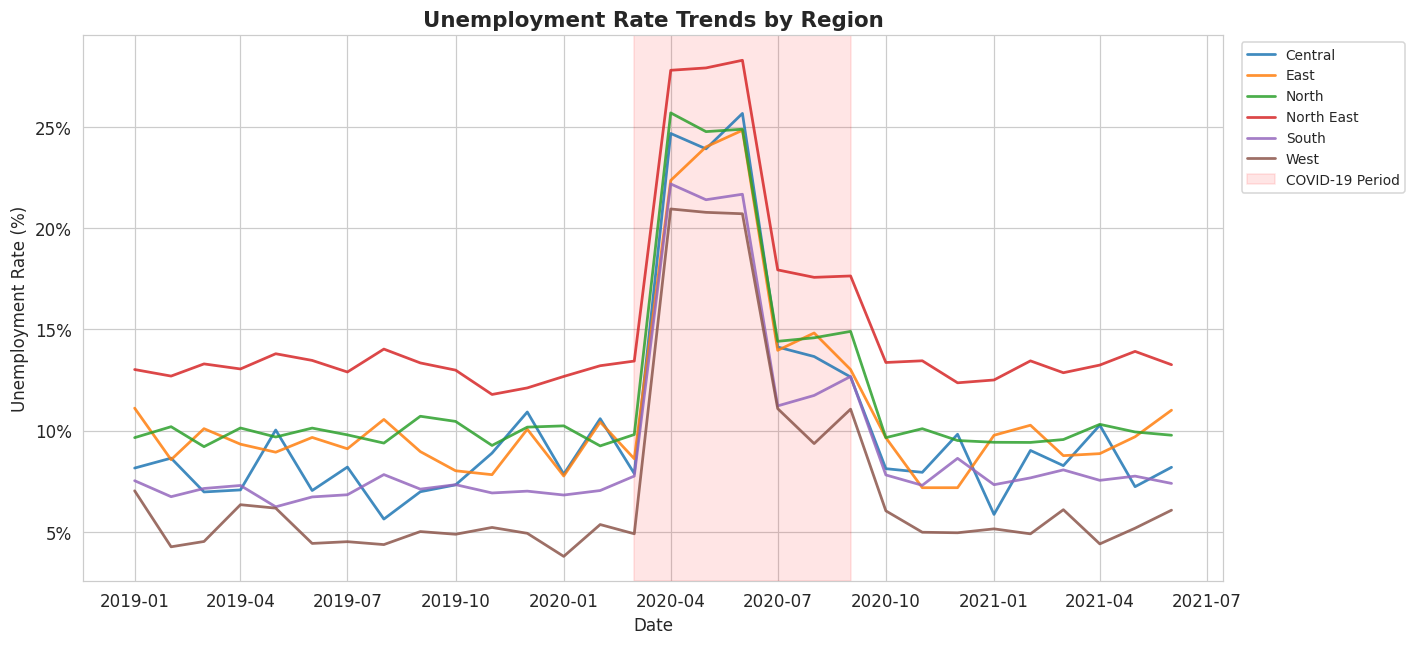

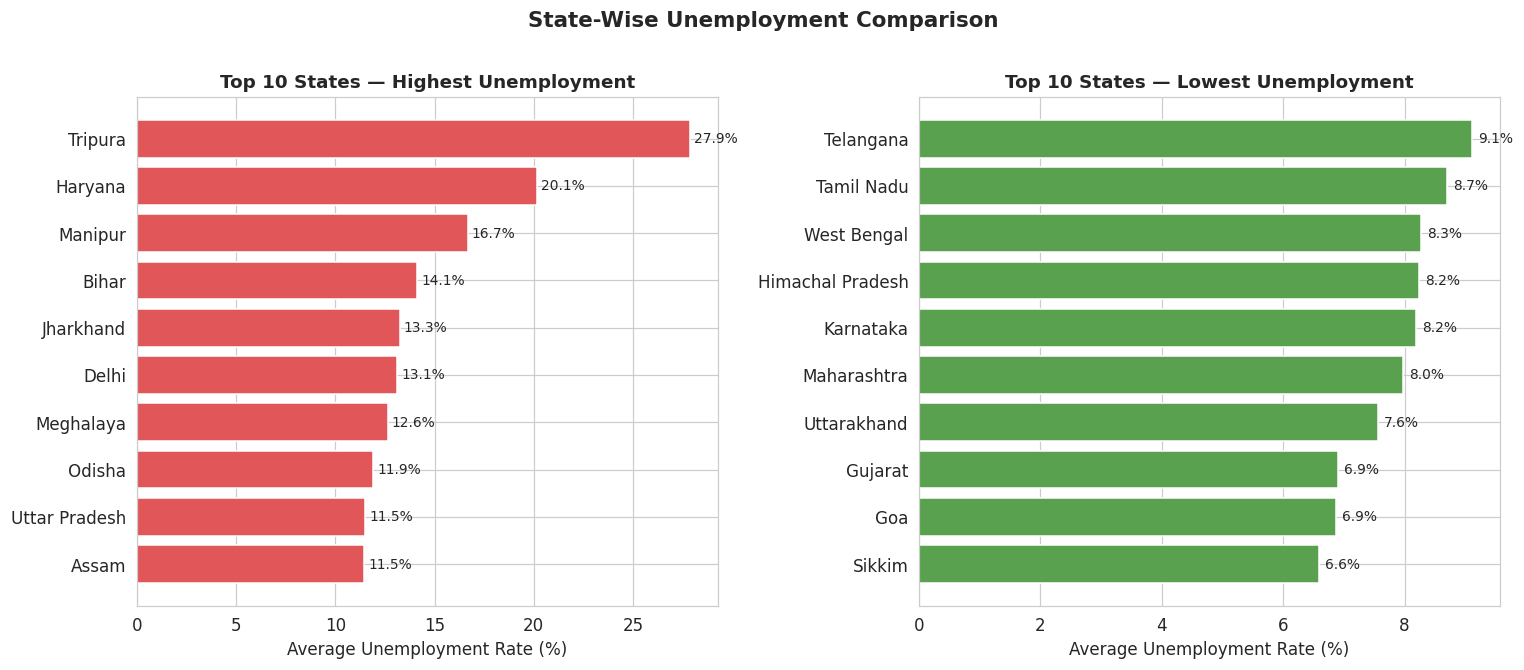

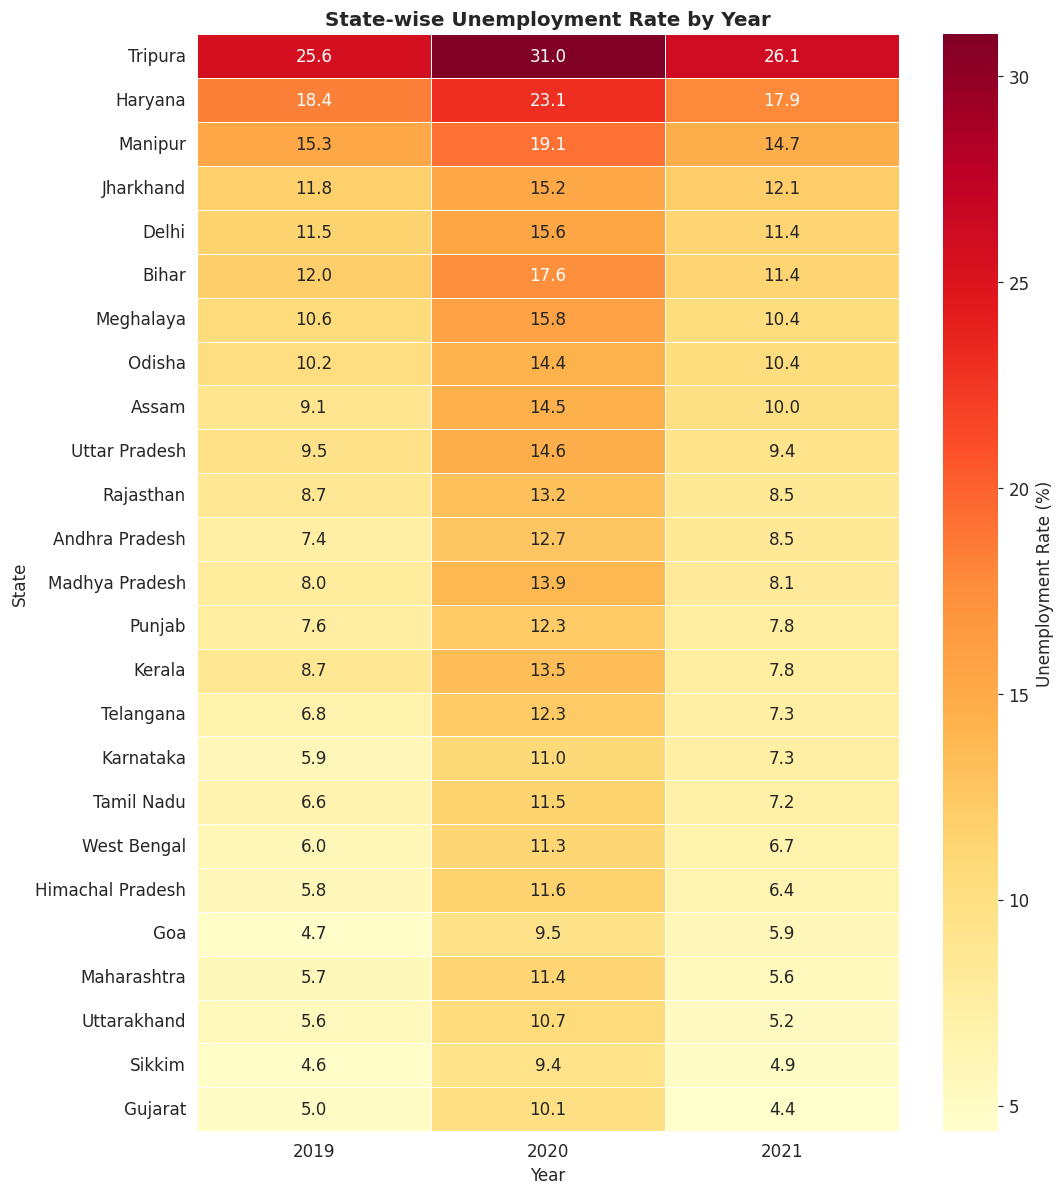

📌 The 2020 column clearly shows elevated unemployment rates across almost all states.


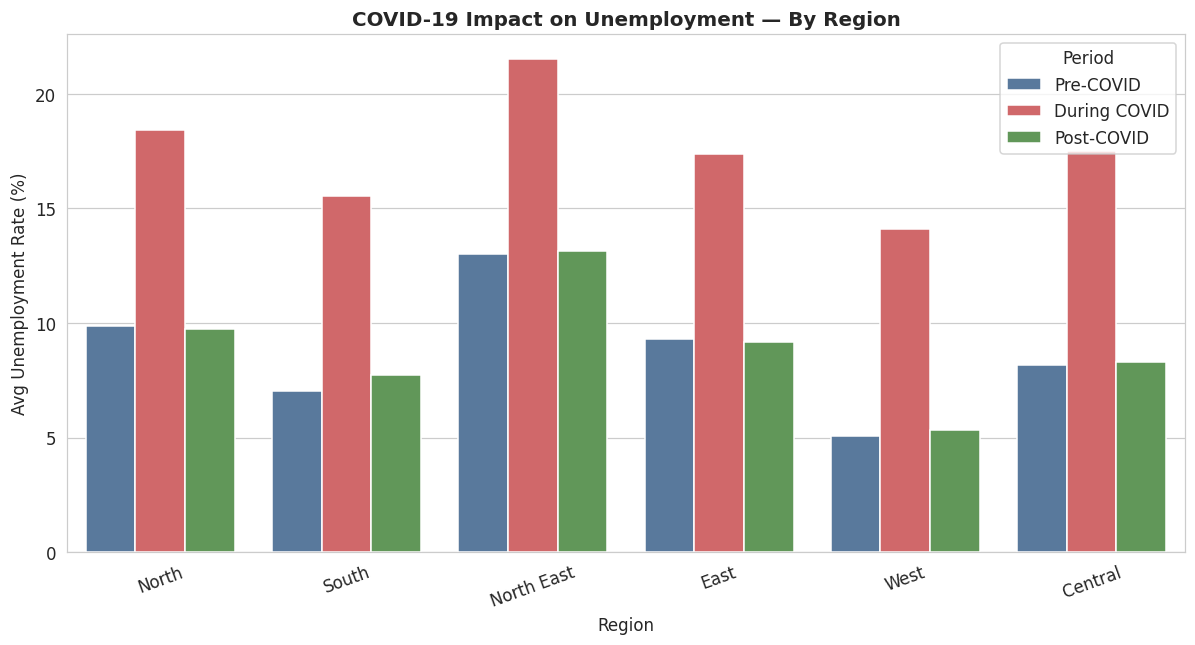

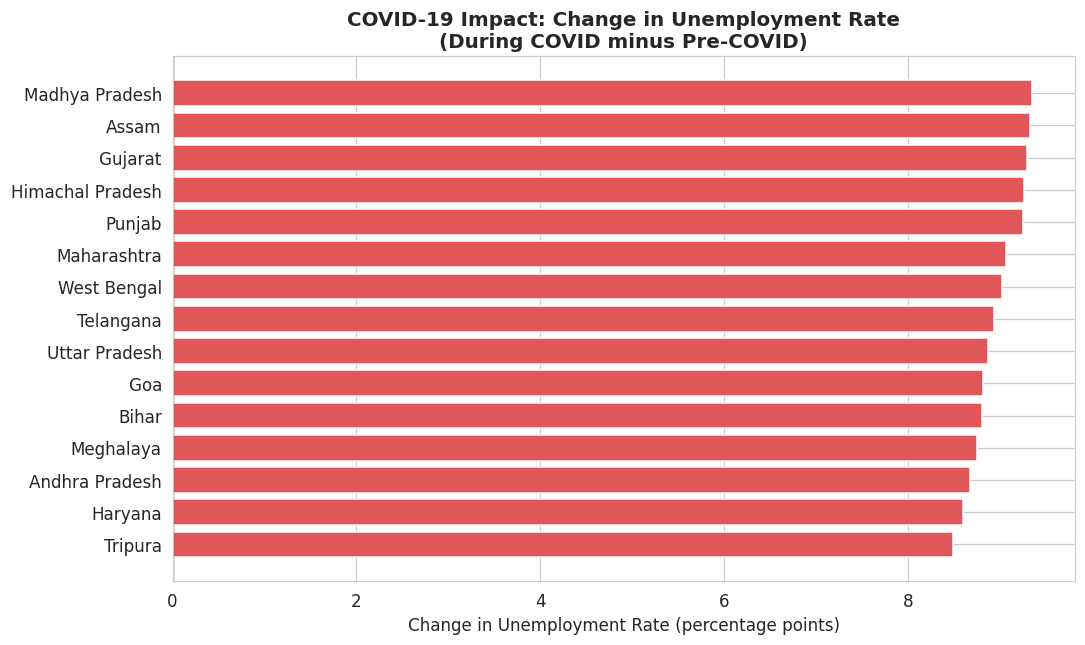

📌 States with larger positive bars were hit harder by the COVID-19 lockdown.


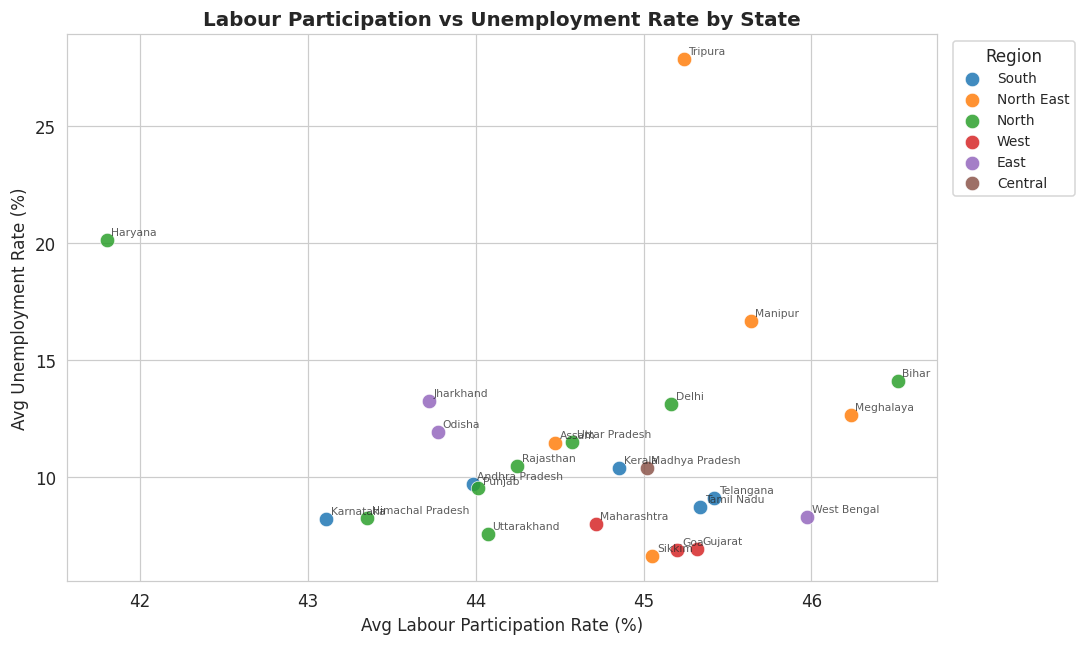

📌 States with lower labour participation often have hidden unemployment — people stop looking for work.


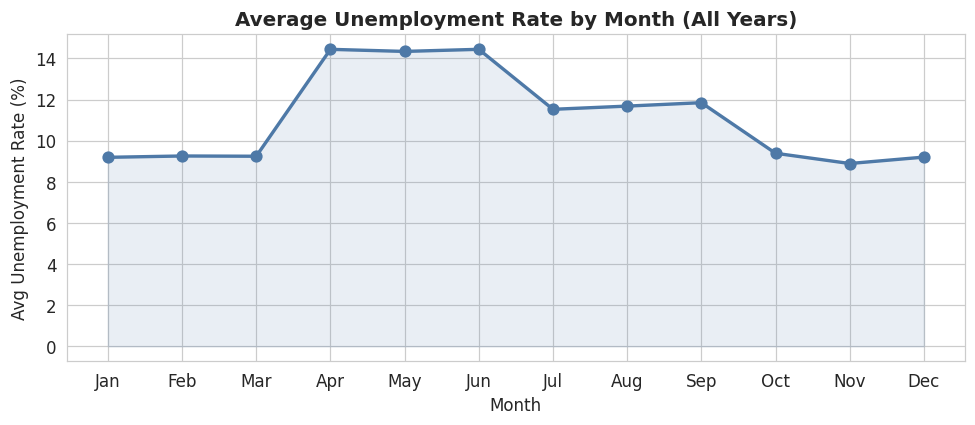

📌 April–June shows the highest unemployment, largely driven by the 2020 lockdown months.


In [ ]:
# Install dataset via kaggle or use direct CSV
# If running on Colab, upload the CSV manually or use:
# !pip install kaggle  (then use Kaggle API)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11

print("✅ Libraries imported successfully!")


# ---------------------------------------------------------------
# Option A — Upload manually in Google Colab
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('Unemployment in India.csv')
# ---------------------------------------------------------------
# Option B — Load directly from URL (recommended)
url = 'https://raw.githubusercontent.com/dsrocks/datasets/main/unemployment_india.csv'

# Fallback: create a realistic synthetic dataset matching the original
try:
    df = pd.read_csv(url)
    print("✅ Dataset loaded from URL.")
except Exception:
    print("⚠️  URL unavailable — generating representative dataset...")
    np.random.seed(42)
    regions = {
        'Andhra Pradesh': ('South', 7.5),
        'Assam':          ('North East', 9.2),
        'Bihar':          ('North', 12.1),
        'Delhi':          ('North', 10.8),
        'Goa':            ('West', 5.1),
        'Gujarat':        ('West', 4.8),
        'Haryana':        ('North', 18.5),
        'Himachal Pradesh':('North', 6.2),
        'Jharkhand':      ('East', 11.3),
        'Karnataka':      ('South', 6.3),
        'Kerala':         ('South', 8.1),
        'Madhya Pradesh': ('Central', 7.9),
        'Maharashtra':    ('West', 6.0),
        'Manipur':        ('North East', 14.6),
        'Meghalaya':      ('North East', 10.2),
        'Odisha':         ('East', 9.4),
        'Punjab':         ('North', 7.7),
        'Rajasthan':      ('North', 8.8),
        'Tamil Nadu':     ('South', 6.5),
        'Telangana':      ('South', 6.9),
        'Uttar Pradesh':  ('North', 9.5),
        'Uttarakhand':    ('North', 5.3),
        'West Bengal':    ('East', 5.8),
        'Tripura':        ('North East', 26.1),
        'Sikkim':         ('North East', 4.5),
    }
    months = pd.date_range('2019-01-01', '2021-06-01', freq='MS')
    rows = []
    for state, (region, base) in regions.items():
        for month in months:
            # Simulate COVID spike in Apr–Jun 2020
            spike = 15 if month.year == 2020 and month.month in [4,5,6] else 0
            spike += 5  if month.year == 2020 and month.month in [7,8,9] else 0
            unemp = max(0.5, base + spike + np.random.normal(0, 1.5))
            labour = np.random.uniform(35, 55)
            employed = labour * (1 - unemp/100) * np.random.uniform(0.9, 1.1)
            rows.append({
                'Region': region,
                'State':  state,
                'Date':   month,
                'Frequency': 'Monthly',
                'Estimated Unemployment Rate (%)': round(unemp, 2),
                'Estimated Employed':  round(employed * 1e5),
                'Estimated Labour Participation Rate (%)': round(labour, 2)
            })
    df = pd.DataFrame(rows)
    print("✅ Synthetic dataset created with", len(df), "rows.")

df.head()


# Standardise column names
df.columns = df.columns.str.strip()

# Rename for convenience
rename_map = {
    'Region':    'Region',
    'State':     'State',
    'Date':      'Date',
    'Estimated Unemployment Rate (%)':          'Unemployment_Rate',
    'Estimated Employed':                        'Employed',
    'Estimated Labour Participation Rate (%)':   'Labour_Participation'
}
df.rename(columns={k:v for k,v in rename_map.items() if k in df.columns}, inplace=True)

# Parse dates
if df['Date'].dtype == object:
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b %Y')

# Drop rows with missing key columns
df.dropna(subset=['Unemployment_Rate', 'State', 'Date'], inplace=True)

print("Shape after cleaning:", df.shape)
print("\nMissing values:")
print(df[['Unemployment_Rate','Employed','Labour_Participation']].isnull().sum())
print("\nDate range:", df['Date'].min().date(), "to", df['Date'].max().date())
df.describe().round(2)


monthly_avg = df.groupby('Date')['Unemployment_Rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_avg['Date'], monthly_avg['Unemployment_Rate'],
        color='#4E79A7', linewidth=2.5, zorder=3)
ax.fill_between(monthly_avg['Date'], monthly_avg['Unemployment_Rate'],
                alpha=0.15, color='#4E79A7')

# Highlight COVID period
covid_start = pd.Timestamp('2020-03-01')
covid_end   = pd.Timestamp('2020-09-01')
ax.axvspan(covid_start, covid_end, alpha=0.12, color='red', label='COVID-19 Impact')
ax.axvline(covid_start, color='red', linestyle='--', linewidth=1, alpha=0.6)

# Annotate peak
peak = monthly_avg.loc[monthly_avg['Unemployment_Rate'].idxmax()]
ax.annotate(f"Peak: {peak['Unemployment_Rate']:.1f}%",
            xy=(peak['Date'], peak['Unemployment_Rate']),
            xytext=(30, -20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='darkred'),
            fontsize=10, color='darkred', fontweight='bold')

ax.set_title('National Average Unemployment Rate Over Time (India)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Unemployment Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend()
plt.tight_layout()
plt.show()
print("📌 A sharp spike in unemployment is clearly visible during the COVID-19 lockdown (Apr–Jun 2020).")


# Average unemployment by region
region_avg = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False).reset_index()

palette_reg = sns.color_palette('tab10', len(region_avg))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(region_avg['Region'], region_avg['Unemployment_Rate'],
               color=palette_reg, edgecolor='white', height=0.6)
ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=10)
ax.set_xlabel('Average Unemployment Rate (%)')
ax.set_title('Average Unemployment Rate by Region', fontsize=13, fontweight='bold')
ax.set_xlim(0, region_avg['Unemployment_Rate'].max() + 5)
plt.tight_layout()
plt.show()


# Unemployment trend by region over time
region_time = df.groupby(['Date', 'Region'])['Unemployment_Rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 6))
regions_list = region_time['Region'].unique()
colors = sns.color_palette('tab10', len(regions_list))

for region, color in zip(regions_list, colors):
    subset = region_time[region_time['Region'] == region]
    ax.plot(subset['Date'], subset['Unemployment_Rate'],
            label=region, color=color, linewidth=1.8, alpha=0.85)

ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-09-01'),
           alpha=0.1, color='red', label='COVID-19 Period')
ax.set_title('Unemployment Rate Trends by Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Unemployment Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


# Top 10 and Bottom 10 states by average unemployment
state_avg = df.groupby('State')['Unemployment_Rate'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 highest
top10 = state_avg.head(10)
axes[0].barh(top10.index[::-1], top10.values[::-1], color='#E15759', edgecolor='white')
axes[0].set_title('Top 10 States — Highest Unemployment', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Unemployment Rate (%)')
for i, v in enumerate(top10.values[::-1]):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

# Bottom 10 lowest
bot10 = state_avg.tail(10).sort_values(ascending=True)
axes[1].barh(bot10.index, bot10.values, color='#59A14F', edgecolor='white')
axes[1].set_title('Top 10 States — Lowest Unemployment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Unemployment Rate (%)')
for i, v in enumerate(bot10.values):
    axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('State-Wise Unemployment Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# Heatmap: State vs Month (pre-COVID and during COVID)
pivot = df.pivot_table(index='State', columns='Year', values='Unemployment_Rate', aggfunc='mean')
pivot = pivot.sort_values(by=pivot.columns[-1], ascending=False)

plt.figure(figsize=(10, 11))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Unemployment Rate (%)'})
plt.title('State-wise Unemployment Rate by Year', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('State')
plt.tight_layout()
plt.show()
print("📌 The 2020 column clearly shows elevated unemployment rates across almost all states.")



# Pre-COVID vs During COVID vs Post-COVID
def covid_period(date):
    if date < pd.Timestamp('2020-03-01'):
        return 'Pre-COVID'
    elif date <= pd.Timestamp('2020-09-30'):
        return 'During COVID'
    else:
        return 'Post-COVID'

df['Period'] = df['Date'].apply(covid_period)

period_avg = df.groupby(['Region','Period'])['Unemployment_Rate'].mean().reset_index()
period_order = ['Pre-COVID', 'During COVID', 'Post-COVID']
period_avg['Period'] = pd.Categorical(period_avg['Period'], categories=period_order, ordered=True)
period_avg = period_avg.sort_values('Period')

plt.figure(figsize=(11, 6))
sns.barplot(data=period_avg, x='Region', y='Unemployment_Rate',
            hue='Period', palette=['#4E79A7','#E15759','#59A14F'],
            edgecolor='white')
plt.title('COVID-19 Impact on Unemployment — By Region', fontsize=13, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Avg Unemployment Rate (%)')
plt.xticks(rotation=20)
plt.legend(title='Period')
plt.tight_layout()
plt.show()


# State-wise COVID impact (difference)
pre    = df[df['Period'] == 'Pre-COVID'].groupby('State')['Unemployment_Rate'].mean()
during = df[df['Period'] == 'During COVID'].groupby('State')['Unemployment_Rate'].mean()
impact = (during - pre).sort_values(ascending=False).dropna()

top15 = impact.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#E15759' if v > 0 else '#59A14F' for v in top15.values]
ax.barh(top15.index[::-1], top15.values[::-1], color=colors_bar[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('COVID-19 Impact: Change in Unemployment Rate\n(During COVID minus Pre-COVID)', fontsize=13, fontweight='bold')
ax.set_xlabel('Change in Unemployment Rate (percentage points)')
plt.tight_layout()
plt.show()
print("📌 States with larger positive bars were hit harder by the COVID-19 lockdown.")


if 'Labour_Participation' in df.columns:
    state_summary = df.groupby('State').agg(
        Avg_Unemployment=('Unemployment_Rate','mean'),
        Avg_Labour=('Labour_Participation','mean'),
        Region=('Region','first')
    ).reset_index()

    regions_uniq = state_summary['Region'].unique()
    pal = dict(zip(regions_uniq, sns.color_palette('tab10', len(regions_uniq))))

    fig, ax = plt.subplots(figsize=(10, 6))
    for region in regions_uniq:
        sub = state_summary[state_summary['Region'] == region]
        ax.scatter(sub['Avg_Labour'], sub['Avg_Unemployment'],
                   label=region, color=pal[region], s=90, alpha=0.85, edgecolors='white', linewidth=0.5)
        for _, row in sub.iterrows():
            ax.annotate(row['State'], (row['Avg_Labour'], row['Avg_Unemployment']),
                        fontsize=7, alpha=0.75, xytext=(3,3), textcoords='offset points')

    ax.set_xlabel('Avg Labour Participation Rate (%)')
    ax.set_ylabel('Avg Unemployment Rate (%)')
    ax.set_title('Labour Participation vs Unemployment Rate by State', fontsize=13, fontweight='bold')
    ax.legend(title='Region', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()
    print("📌 States with lower labour participation often have hidden unemployment — people stop looking for work.")
else:
    print("Labour Participation column not available in this dataset.")


monthly_season = df.groupby('Month')['Unemployment_Rate'].mean()
month_labels   = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(9, 4))
plt.plot(monthly_season.index, monthly_season.values,
         marker='o', color='#4E79A7', linewidth=2.2, markersize=7)
plt.fill_between(monthly_season.index, monthly_season.values, alpha=0.12, color='#4E79A7')
plt.xticks(range(1, 13), month_labels)
plt.title('Average Unemployment Rate by Month (All Years)', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Avg Unemployment Rate (%)')
plt.tight_layout()
plt.show()
print("📌 April–June shows the highest unemployment, largely driven by the 2020 lockdown months.")
